In [42]:
import pandas as pd
import networkx as nx
import json
from collections import defaultdict
import community.community_louvain as community_louvain

In [12]:
# =========================================================
# LOAD JSON
# =========================================================

with open("./doi_10_5061_dryad_dr7sqv9v8__v20200626/NJC19_network_data_and_code/NJC19_network.json") as f:
    data = json.load(f)

# =========================================================
# CREATE NETWORK
# =========================================================

B = nx.MultiDiGraph()

# =========================================================
# ACTIVITY CLASSIFICATION
# =========================================================

activity_map = {
    "Consumption (import)": {
        "category": "import",
        "sign": 1
    },

    "Production (export)": {
        "category": "export",
        "sign": 1
    },

    "Consumption (import), Production (export)": {
        "category": "exchange",
        "sign": 1
    },

    "Macromolecule degradation": {
        "category": "degradation",
        "sign": 1
    },

    "Consumption (import) (-)": {
        "category": "import",
        "sign": -1
    },

    "Production (export) (-)": {
        "category": "export",
        "sign": -1
    },

    "Macromolecule degradation (-)": {
        "category": "degradation",
        "sign": -1
    }
}

# =========================================================
# BUILD NETWORK
# =========================================================

for interaction_id, interaction in data.items():

    species = interaction["Species"]

    metabolite = interaction[
        "Small-molecule metabolite or macromolecule"
    ]

    activity = interaction["Metabolic activity"]

    refs = interaction["Ref. #"]

    # -----------------------------------------
    # Parse activity information
    # -----------------------------------------

    parsed = activity_map[activity]

    category = parsed["category"]
    sign = parsed["sign"]

    # -----------------------------------------
    # Add species node
    # -----------------------------------------

    B.add_node(
        species,
        node_type="species"
    )

    # -----------------------------------------
    # Add metabolite node
    # -----------------------------------------

    B.add_node(
        metabolite,
        node_type="metabolite"
    )

    # -----------------------------------------
    # Add edge
    # -----------------------------------------

    B.add_edge(
        species,
        metabolite,

        interaction_id=interaction_id,

        activity=activity,
        category=category,

        sign=sign,

        refs=refs
    )

print("Nodes:", B.number_of_nodes())
print("Edges:", B.number_of_edges())

Nodes: 1127
Edges: 9136


In [17]:
metabolite_import_degree = defaultdict(set)

for u, v, d in B.edges(data=True):

    if (
        d["sign"] == 1
        and d["category"] in [
            "import",
            "exchange",
            "degradation"
        ]
    ):

        species = u
        metabolite = v

        metabolite_import_degree[metabolite].add(species)

# counts
metabolite_import_degree = {
    m: len(species)
    for m, species in metabolite_import_degree.items()
}

In [18]:
top_hubs = sorted(
    metabolite_import_degree.items(),
    key=lambda x: x[1],
    reverse=True
)

top_hubs[:20]

[('D-Glucose (Glucose)', 305),
 ('D-Fructose (Fructose)', 209),
 ('Lactose', 205),
 ('Pantothenic acid (Vitamin B5, Pantothenate)', 195),
 ('Maltose', 179),
 ('Sucrose', 154),
 ('D-Mannose (Mannose)', 140),
 ('Cellobiose', 135),
 ('D-Galactose', 129),
 ('D-Mannitol (Mannitol)', 117),
 ('CO2', 107),
 ('Raffinose', 106),
 ('H2 (Hydrogen)', 96),
 ('D-Arabinose (L-Arabinose, Arabinose, L-Arabinopyranose, L-Arabinofuranose)',
  96),
 ('Trehalose', 94),
 ('D-Xylose (Xylose)', 93),
 ('Nitrate (NO3-)', 91),
 ('Starch (Amylopectin, Amylose, 1,4-alpha-D-Glucan, Pullulan, Resistant starch, Glycogen)',
  89),
 ('D-Ribose (Ribose)', 74),
 ('Acetate', 74)]

In [19]:

resource_activities = {
    "Consumption (import)",
    "Consumption (import), Production (export)",
    "Macromolecule degradation"
}

# =========================================================
# RESOURCE BIPARTITE NETWORK
# =========================================================

B_resource = nx.Graph()

for u, v, d in B.edges(data=True):

    if (
        d["activity"] in resource_activities
        and d["sign"] == 1
    ):

        species = u
        metabolite = v

        B_resource.add_node(
            species,
            bipartite="species"
        )

        B_resource.add_node(
            metabolite,
            bipartite="metabolite"
        )

        B_resource.add_edge(species, metabolite)

In [20]:
species_nodes = {
    n for n, d in B_resource.nodes(data=True)
    if d["bipartite"] == "species"
}

metabolite_nodes = {
    n for n, d in B_resource.nodes(data=True)
    if d["bipartite"] == "metabolite"
}

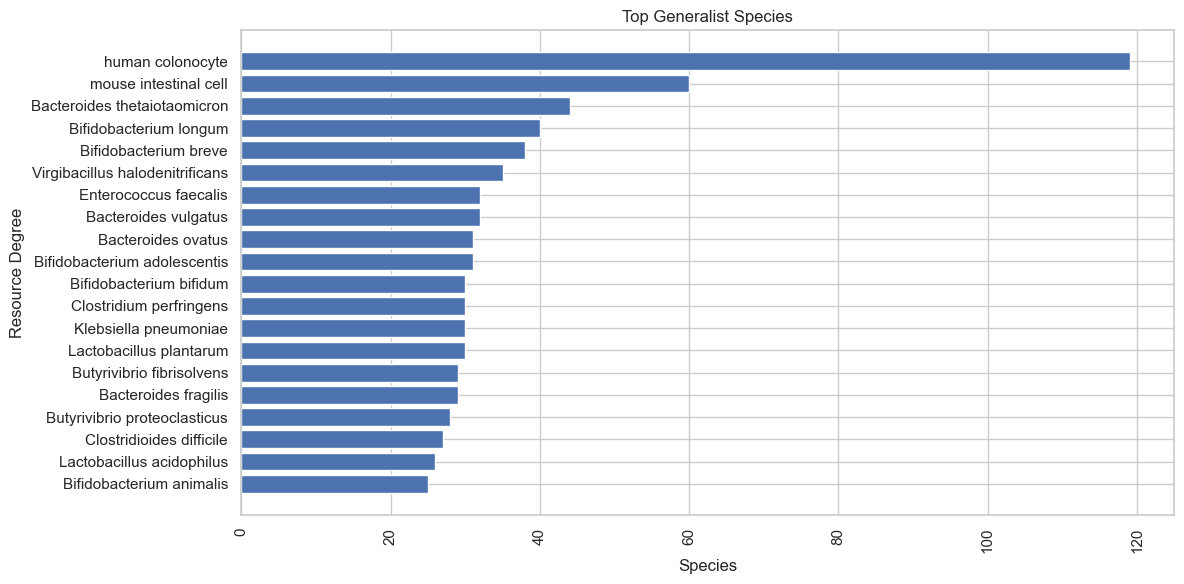

In [23]:
species_degree = dict(B_resource.degree(species_nodes))

species_degree_sorted = sorted(
    species_degree.items(),
    key=lambda x: x[1],
    reverse=True
)

top_n = 20

top_species = species_degree_sorted[:top_n]

names = [x[0] for x in top_species]
degrees = [x[1] for x in top_species]

names = names[::-1]
degrees = degrees[::-1]

plt.figure(figsize=(12,6))

plt.barh(names, degrees)

plt.xticks(rotation=90)

plt.ylabel("Resource Degree")
plt.xlabel("Species")

plt.title("Top Generalist Species")

plt.tight_layout()
plt.show()

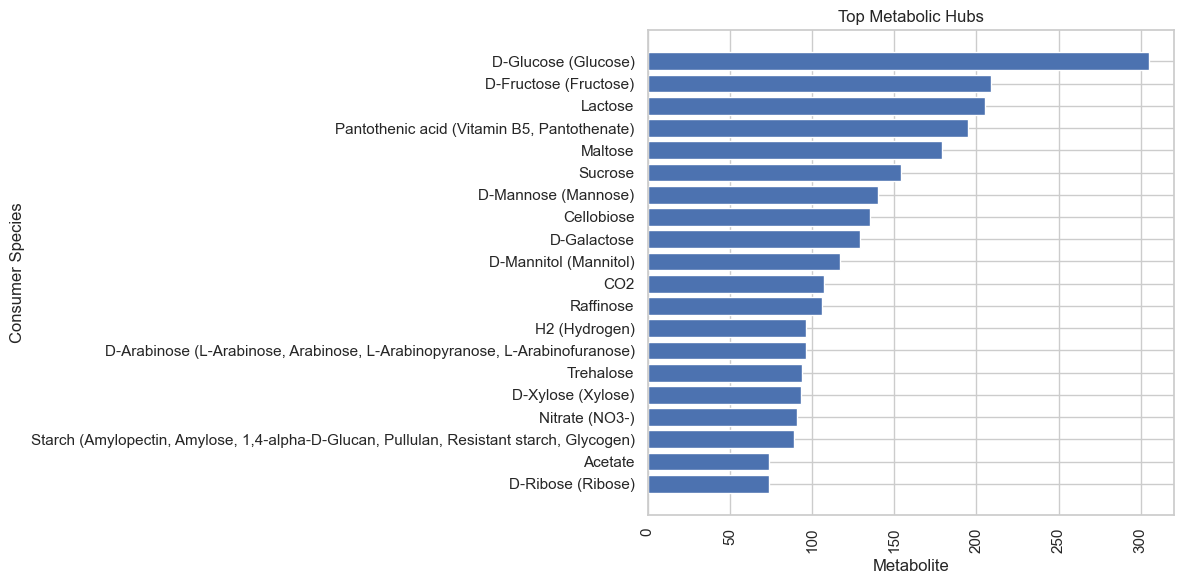

In [24]:
metabolite_degree = dict(
    B_resource.degree(metabolite_nodes)
)

metabolite_degree_sorted = sorted(
    metabolite_degree.items(),
    key=lambda x: x[1],
    reverse=True
)

top_n = 20

top_metabolites = metabolite_degree_sorted[:top_n]

names = [x[0] for x in top_metabolites]
degrees = [x[1] for x in top_metabolites]

names = names[::-1]
degrees = degrees[::-1]

plt.figure(figsize=(12,6))

plt.barh(names, degrees)

plt.xticks(rotation=90)

plt.ylabel("Consumer Species")
plt.xlabel("Metabolite")

plt.title("Top Metabolic Hubs")

plt.tight_layout()
plt.show()

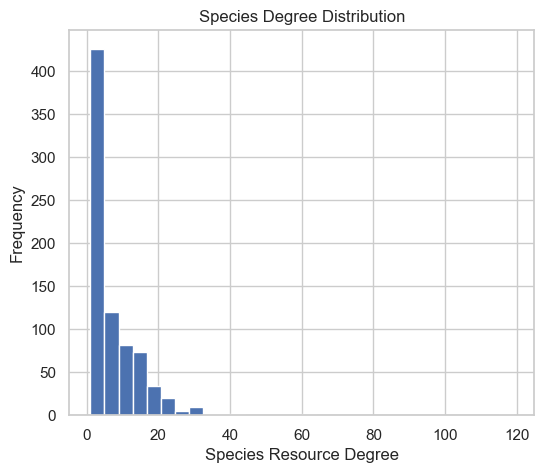

In [25]:
species_degree_values = list(species_degree.values())

plt.figure(figsize=(6,5))

plt.hist(
    species_degree_values,
    bins=30
)

plt.xlabel("Species Resource Degree")
plt.ylabel("Frequency")

plt.title("Species Degree Distribution")

plt.show()

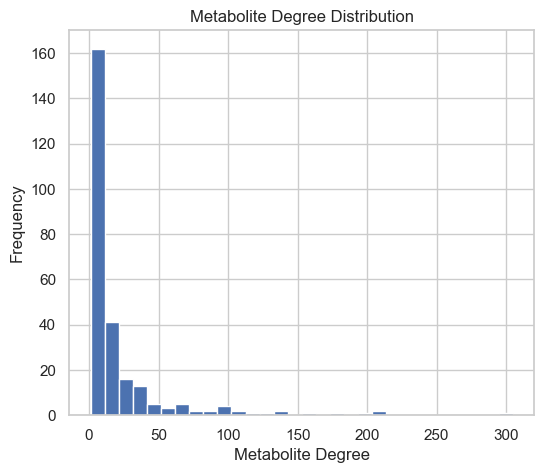

In [26]:
metabolite_degree_values = list(
    metabolite_degree.values()
)

plt.figure(figsize=(6,5))

plt.hist(
    metabolite_degree_values,
    bins=30
)

plt.xlabel("Metabolite Degree")
plt.ylabel("Frequency")

plt.title("Metabolite Degree Distribution")

plt.show()

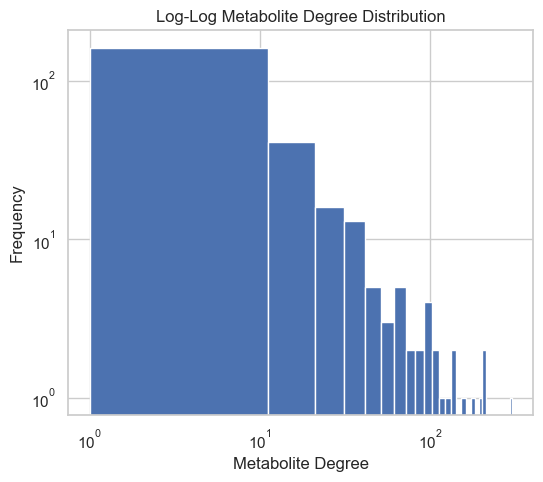

In [82]:
plt.figure(figsize=(6,5))

plt.hist(
    metabolite_degree_values,
    bins=30,
    log=True
)

plt.xscale("log")

plt.xlabel("Metabolite Degree")
plt.ylabel("Frequency")

plt.title("Log-Log Metabolite Degree Distribution")

plt.show()

CODE — Betweenness

Use inverse weights because:

higher overlap = shorter ecological distance

In [ ]:
competition_graph_distance = competition_graph.copy()

for u, v, d in competition_graph_distance.edges(data=True):

    d["distance"] = 1 / d["weight"]

betweenness_sorted = sorted(
    betweenness.items(),
    key=lambda x: x[1],
    reverse=True
)


betweenness = nx.betweenness_centrality(
    competition_graph_distance,
    weight="distance"
)

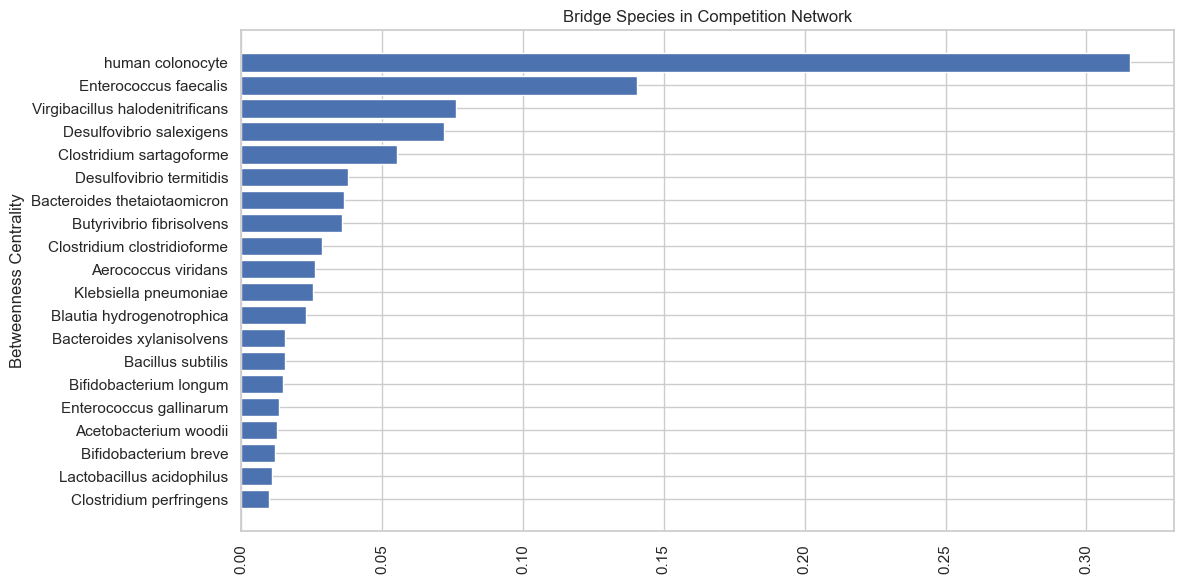

In [40]:
top_n = 20

top_species = betweenness_sorted[:top_n]

names = [x[0] for x in top_species]
values = [x[1] for x in top_species]

plt.figure(figsize=(12,6))

names = names[::-1]
values = values[::-1]

plt.barh(names, values)

plt.xticks(rotation=90)

plt.ylabel("Betweenness Centrality")

plt.title("Bridge Species in Competition Network")

plt.tight_layout()
plt.show()

# Community

In [ ]:
partition = community_louvain.best_partition(
    competition_graph,
    weight="weight"
)

In [43]:
community_sizes = Counter(partition.values())

community_sizes

Counter({2: 258, 0: 207, 1: 192, 3: 120})

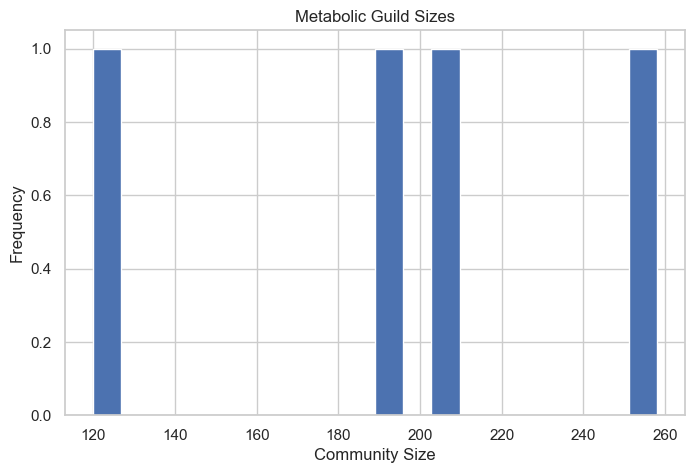

In [44]:
sizes = list(community_sizes.values())

plt.figure(figsize=(8,5))

plt.hist(sizes, bins=20)

plt.xlabel("Community Size")
plt.ylabel("Frequency")

plt.title("Metabolic Guild Sizes")

plt.show()

In [55]:
communities = list(set(partition.values()))

community_colors = {
    community: i
    for i, community in enumerate(communities)
}

node_colors = [
    community_colors[partition[node]]
    for node in competition_graph.nodes()
]

node_strength = dict(
    competition_graph.degree(weight="weight")
)

node_sizes = [
    node_strength[node] * 2
    for node in competition_graph.nodes()
]

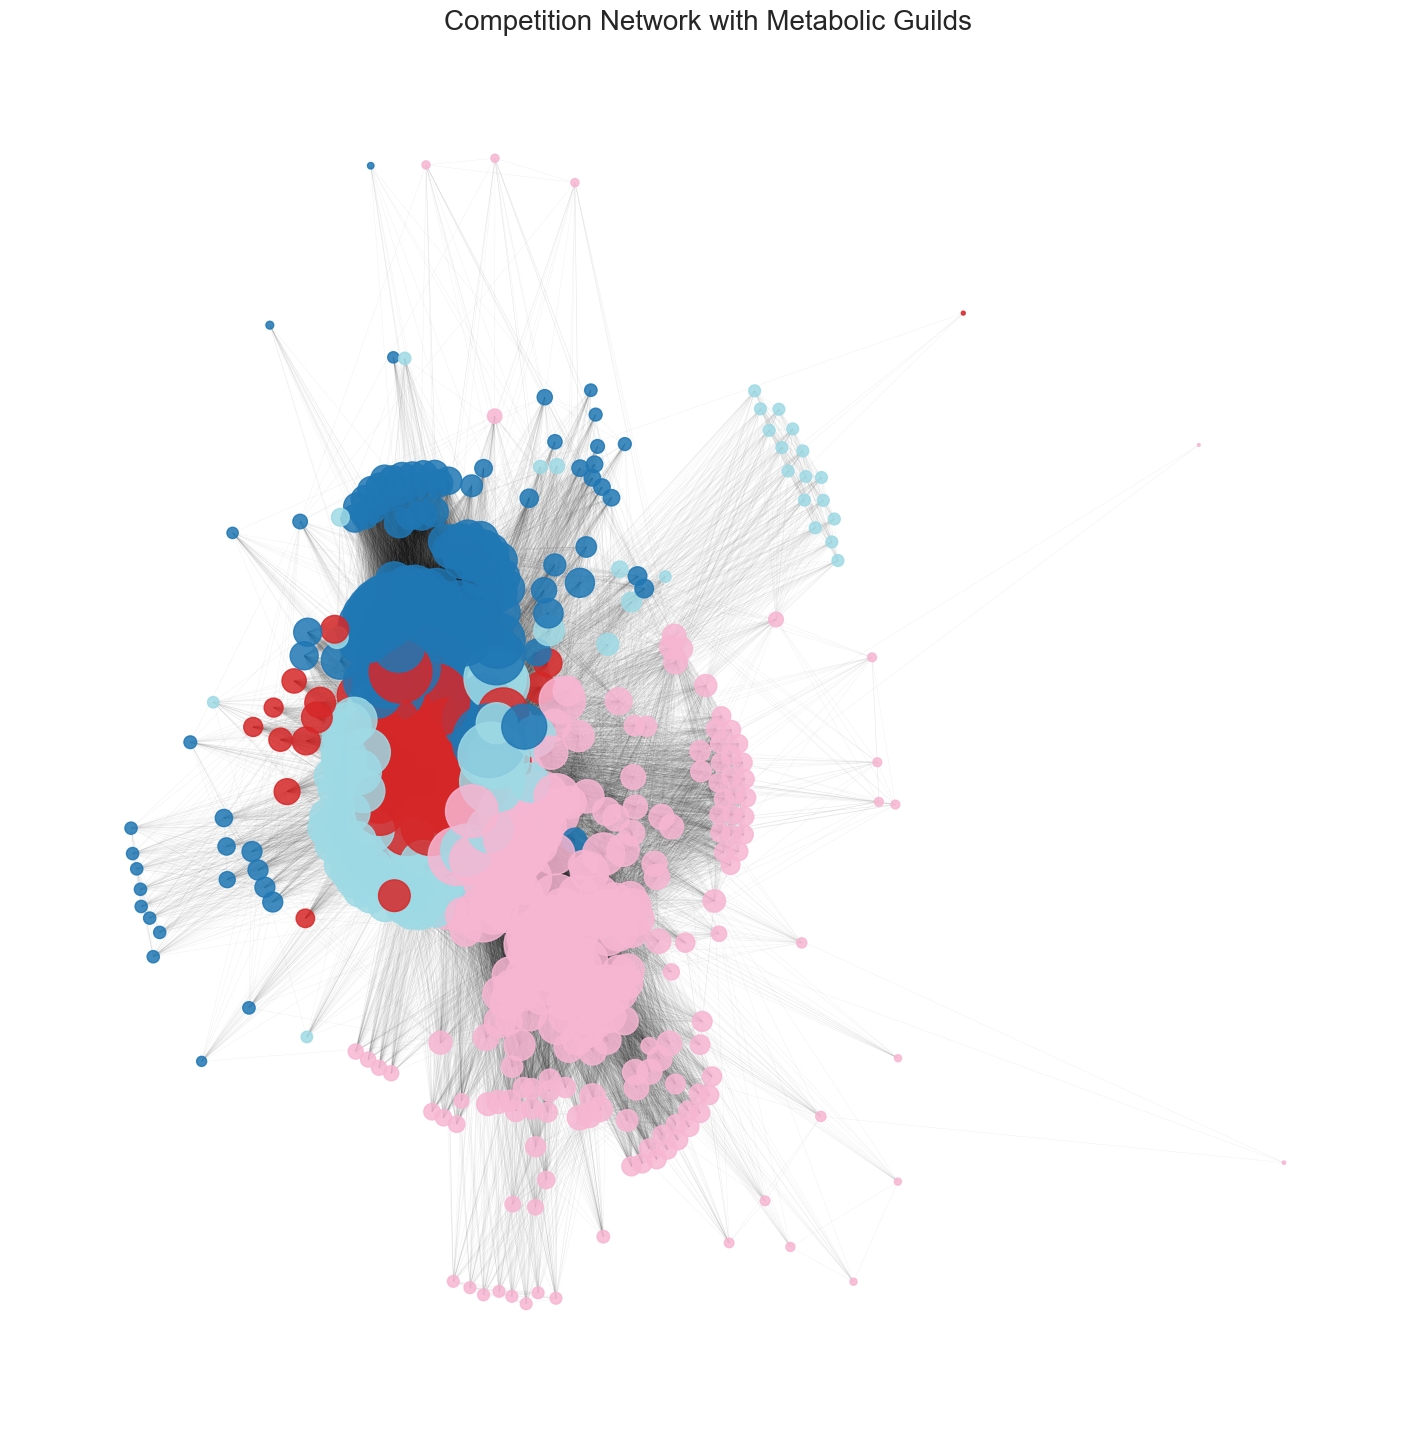

In [57]:
plt.figure(figsize=(18,18))

nx.draw_networkx_nodes(
    competition_graph,
    pos,

    node_color=node_colors,

    cmap=plt.cm.tab20,

    node_size=node_sizes,

    alpha=0.85
)

nx.draw_networkx_edges(
    competition_graph,
    pos,

    alpha=0.05,

    width=0.4
)

plt.title(
    "Competition Network with Metabolic Guilds",
    fontsize=20
)

plt.axis("off")

plt.show()

# Netedness

In [46]:
species_list = list(species_nodes)
metabolite_list = list(metabolite_nodes)

matrix = pd.DataFrame(
    0,
    index=species_list,
    columns=metabolite_list
)

for s, m in B_resource.edges():

    if s in species_nodes:

        matrix.loc[s, m] = 1

    else:

        matrix.loc[m, s] = 1

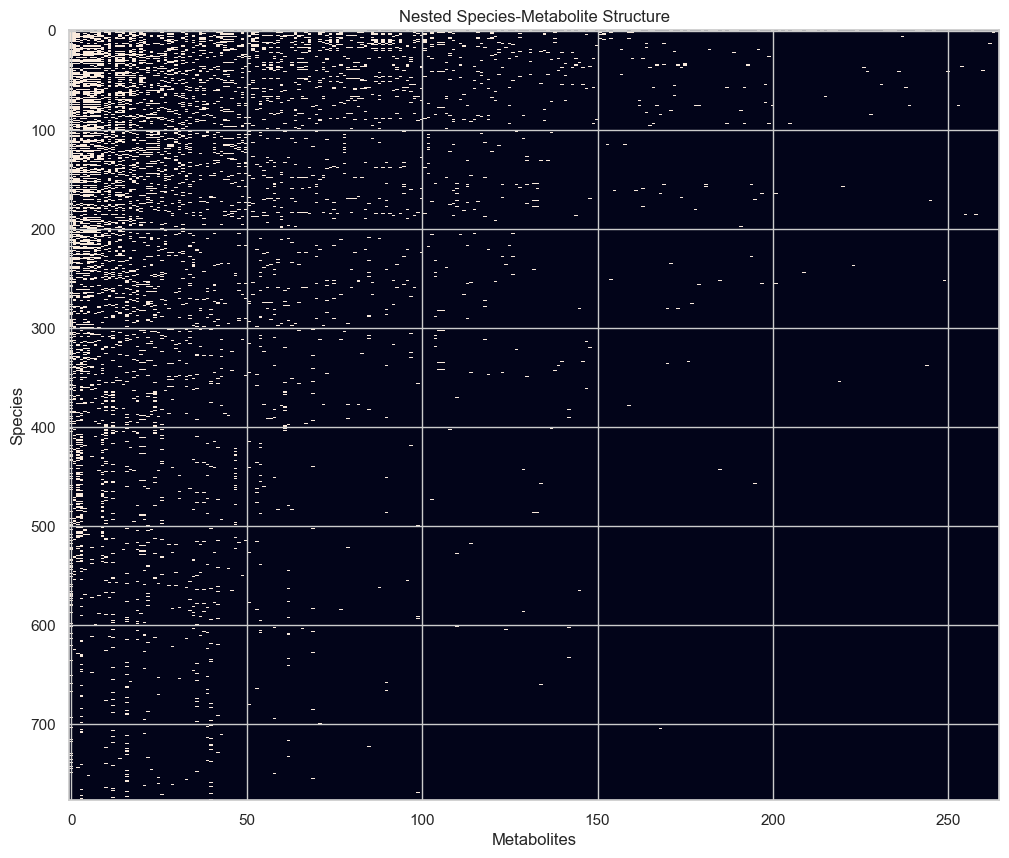

In [48]:
species_order = matrix.sum(axis=1).sort_values(
    ascending=False
).index

metabolite_order = matrix.sum(axis=0).sort_values(
    ascending=False
).index

matrix_sorted = matrix.loc[
    species_order,
    metabolite_order
]

plt.figure(figsize=(12,10))

plt.imshow(
    matrix_sorted.values,
    aspect="auto",
    interpolation="none"
)

plt.xlabel("Metabolites")
plt.ylabel("Species")

plt.title("Nested Species-Metabolite Structure")

plt.show()

# Robustness

In [49]:
B_robust = B_resource.copy()

# remove top metabolites one by one
sorted_metabolites = sorted(
    metabolite_degree.items(),
    key=lambda x: x[1],
    reverse=True
)

largest_component_sizes = []

for metabolite, _ in sorted_metabolites[:50]:

    if metabolite in B_robust:

        B_robust.remove_node(metabolite)

    components = list(
        nx.connected_components(B_robust)
    )

    largest = max(len(c) for c in components)

    largest_component_sizes.append(largest)

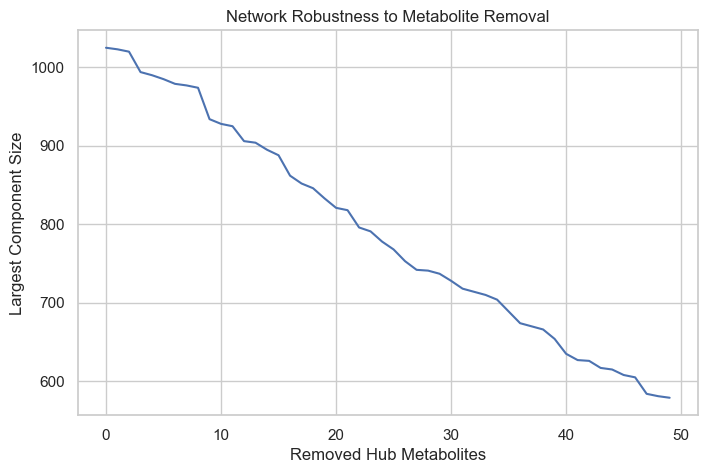

In [50]:
plt.figure(figsize=(8,5))

plt.plot(largest_component_sizes)

plt.xlabel("Removed Hub Metabolites")
plt.ylabel("Largest Component Size")

plt.title("Network Robustness to Metabolite Removal")

plt.show()

# Competition Network

A weighted monopartite projection of the bipartite species–metabolite network was constructed to infer potential competition between microbial species. Two species were connected if they shared at least one positively utilized metabolite through import or macromolecule degradation activities. Edge weights represented the intensity of metabolic niche overlap

In [28]:
competition_graph = nx.Graph()

metabolite_consumers = defaultdict(set)

# =========================================================
# metabolite -> consumer species
# =========================================================

for species, metabolite in B_resource.edges():

    if species in species_nodes:

        metabolite_consumers[metabolite].add(species)

    else:

        metabolite_consumers[species].add(metabolite)

# =========================================================
# projection
# =========================================================

for metabolite, consumers in metabolite_consumers.items():

    consumers = list(consumers)

    for i in range(len(consumers)):
        for j in range(i + 1, len(consumers)):

            s1 = consumers[i]
            s2 = consumers[j]

            if competition_graph.has_edge(s1, s2):

                competition_graph[s1][s2]["weight"] += 1

            else:

                competition_graph.add_edge(
                    s1,
                    s2,
                    weight=1
                )

otal competition intensity.

A species may:

compete with many species weakly
OR few species strongly

Strength captures this.

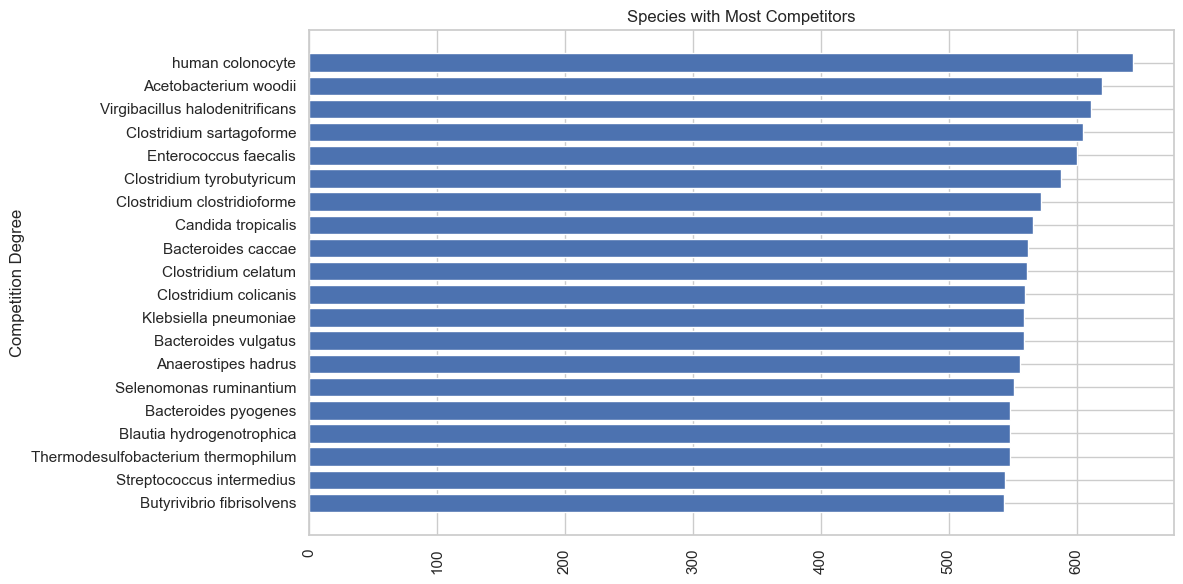

In [33]:
competition_degree = dict(
    competition_graph.degree()
)

competition_degree_sorted = sorted(
    competition_degree.items(),
    key=lambda x: x[1],
    reverse=True
)

top_n = 20

top_species = competition_degree_sorted[:top_n]

names = [x[0] for x in top_species]
degrees = [x[1] for x in top_species]

names = names[::-1]
degrees = degrees[::-1]

plt.figure(figsize=(12,6))

plt.barh(names, degrees)

plt.xticks(rotation=90)

plt.ylabel("Competition Degree")

plt.title("Species with Most Competitors")

plt.tight_layout()
plt.show()

Ecological meaning

These may represent:

dominant generalists
strong niche occupiers
ecological pressure centers

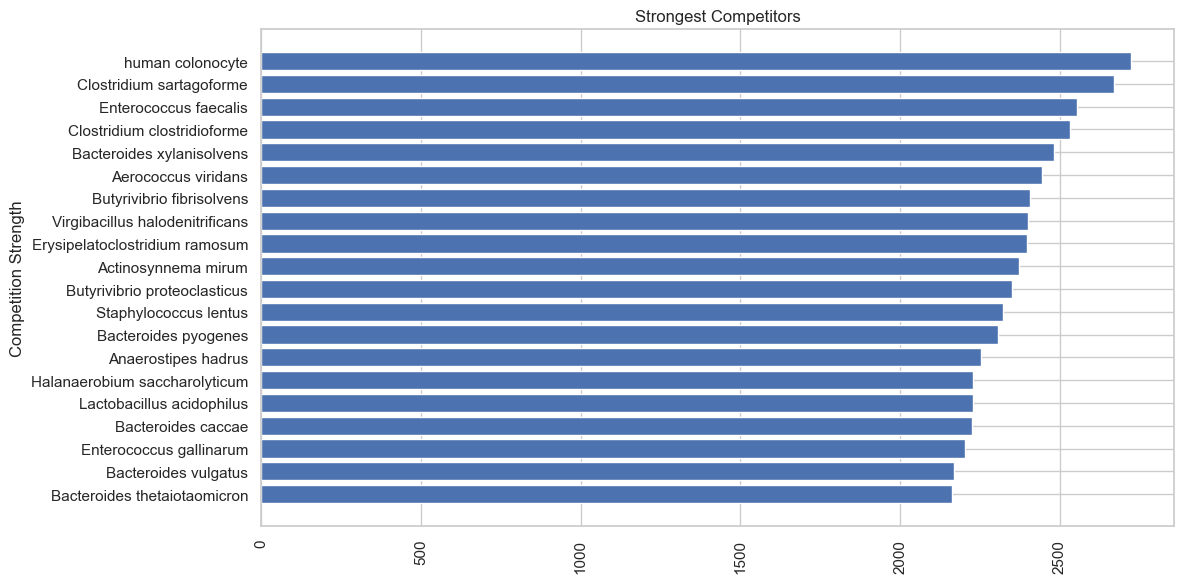

In [35]:
competition_strength = dict(
    competition_graph.degree(weight="weight")
)

competition_strength_sorted = sorted(
    competition_strength.items(),
    key=lambda x: x[1],
    reverse=True
)

top_n = 20

top_species = competition_strength_sorted[:top_n]

names = [x[0] for x in top_species]
strengths = [x[1] for x in top_species]

names = names[::-1]
strengths = strengths[::-1]

plt.figure(figsize=(12,6))

plt.barh(names, strengths)

plt.xticks(rotation=90)

plt.ylabel("Competition Strength")

plt.title("Strongest Competitors")

plt.tight_layout()
plt.show()

High clustering:

tightly overlapping guilds
dense competition niches

Low clustering:

bridge species
unique ecological roles

Do my competitors also compete with each other?”

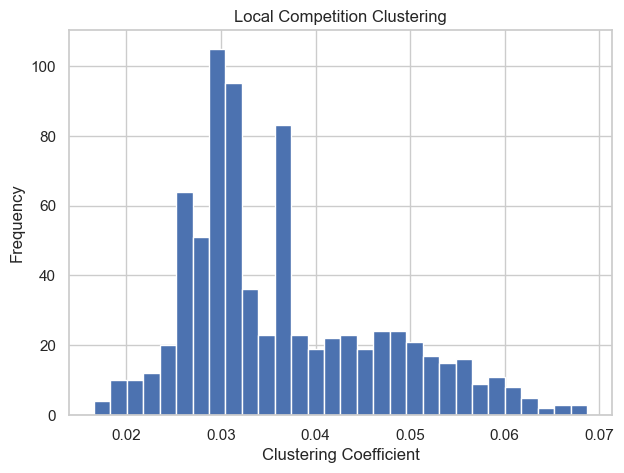

In [58]:
clustering = nx.clustering(
    competition_graph,
    weight="weight"
)

clustering_values = list(
    clustering.values()
)

plt.figure(figsize=(7,5))

plt.hist(clustering_values, bins=30)

plt.xlabel("Clustering Coefficient")
plt.ylabel("Frequency")

plt.title("Local Competition Clustering")

plt.show()

Ecological meaning

High betweenness species:

connect metabolic guilds
increase ecological connectivity
may stabilize ecosystem structure

VERY important.

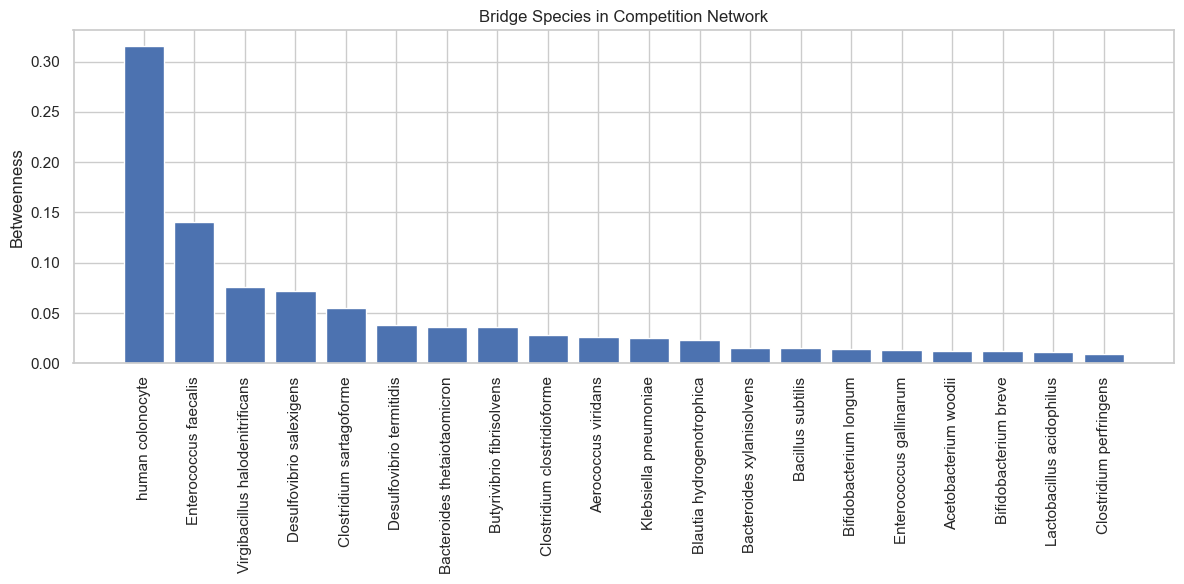

In [60]:
competition_graph_distance = competition_graph.copy()

for u, v, d in competition_graph_distance.edges(data=True):

    d["distance"] = 1 / d["weight"]

	
betweenness = nx.betweenness_centrality(
    competition_graph_distance,
    weight="distance"
)

betweenness_sorted = sorted(
    betweenness.items(),
    key=lambda x: x[1],
    reverse=True
)

top_n = 20

top_species = betweenness_sorted[:top_n]

names = [x[0] for x in top_species]
values = [x[1] for x in top_species]

plt.figure(figsize=(12,6))

plt.bar(names, values)

plt.xticks(rotation=90)

plt.ylabel("Betweenness")

plt.title("Bridge Species in Competition Network")

plt.tight_layout()

plt.show()

Community

In [61]:
partition = community_louvain.best_partition(
    competition_graph,
    weight="weight"
)

In [62]:
modularity = community_louvain.modularity(
    partition,
    competition_graph,
    weight="weight"
)

print(modularity)

0.19037587994892924


In [63]:
assortativity = nx.degree_assortativity_coefficient(
    competition_graph
)

print(assortativity)

0.11625881690304746


Robustness

In [64]:
G = competition_graph.copy()

largest_components = []

sorted_nodes = sorted(
    competition_strength.items(),
    key=lambda x: x[1],
    reverse=True
)

for node, _ in sorted_nodes[:100]:

    G.remove_node(node)

    if len(G.nodes()) == 0:
        break

    largest = len(
        max(
            nx.connected_components(G),
            key=len
        )
    )

    largest_components.append(largest)

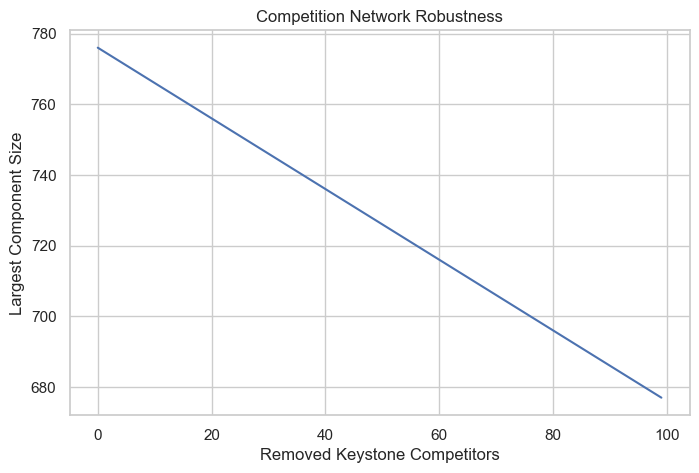

In [65]:
plt.figure(figsize=(8,5))

plt.plot(largest_components)

plt.xlabel("Removed Keystone Competitors")
plt.ylabel("Largest Component Size")

plt.title("Competition Network Robustness")

plt.show()

In [66]:
strongest_edges = sorted(
    competition_graph.edges(data=True),
    key=lambda x: x[2]["weight"],
    reverse=True
)

for u, v, d in strongest_edges[:20]:

    print(u, "<->", v, d["weight"])

human colonocyte <-> mouse intestinal cell 42
Bifidobacterium breve <-> Bifidobacterium longum 31
Bifidobacterium adolescentis <-> Bifidobacterium longum 30
Bacteroides thetaiotaomicron <-> Bacteroides ovatus 29
Bifidobacterium longum <-> Bifidobacterium bifidum 28
Bifidobacterium breve <-> Bifidobacterium adolescentis 27
Bifidobacterium breve <-> Bifidobacterium bifidum 27
Butyrivibrio proteoclasticus <-> Butyrivibrio fibrisolvens 26
Bifidobacterium adolescentis <-> Bifidobacterium bifidum 26
Bifidobacterium animalis <-> Bifidobacterium longum 25
human colonocyte <-> Virgibacillus halodenitrificans 25
Bifidobacterium breve <-> Bifidobacterium animalis 24
Bacteroides thetaiotaomicron <-> Bacteroides vulgatus 24
Bifidobacterium animalis <-> Bifidobacterium bifidum 24
Bifidobacterium adolescentis <-> Bifidobacterium animalis 23
Clostridioides difficile <-> human colonocyte 22
Bifidobacterium breve <-> Lactobacillus acidophilus 21
Bacteroides thetaiotaomicron <-> Bacteroides fragilis 21
B

In [67]:
density = nx.density(
    competition_graph
)

print(density)

0.3678236410195173


LV

In [ ]:
#normalization
max_weight = max(
    d["weight"]
    for _, _, d in competition_graph.edges(data=True)
)

alpha = {}

for u, v, d in competition_graph.edges(data=True):

    value = d["weight"] / max_weight

    alpha[(u, v)] = value
    alpha[(v, u)] = value


species = list(
    competition_graph.nodes()
)

n = len(species)

species_index = {
    s: i
    for i, s in enumerate(species)
}

r = np.random.uniform(
    0.5,
    1.5,
    n
)

K = np.random.uniform(
    50,
    100,
    n
)

N0 = np.random.uniform(
    1,
    10,
    n
)

#INTERACTION MATRIX
A = np.zeros((n, n))

for (u, v), value in alpha.items():

    i = species_index[u]
    j = species_index[v]

    A[i, j] = value


np.fill_diagonal(A, 1.0)


def lotka_volterra(N, t, r, K, A):

    dNdt = np.zeros(len(N))

    for i in range(len(N)):

        interaction_term = np.sum(
            A[i] * N
        )

        dNdt[i] = (
            r[i]
            * N[i]
            * (
                1
                - interaction_term / K[i]
            )
        )

    return dNdt

In [69]:
from scipy.integrate import odeint

t = np.linspace(0, 100, 1000)

solution = odeint(
    lotka_volterra,
    N0,
    t,
    args=(r, K, A)
)

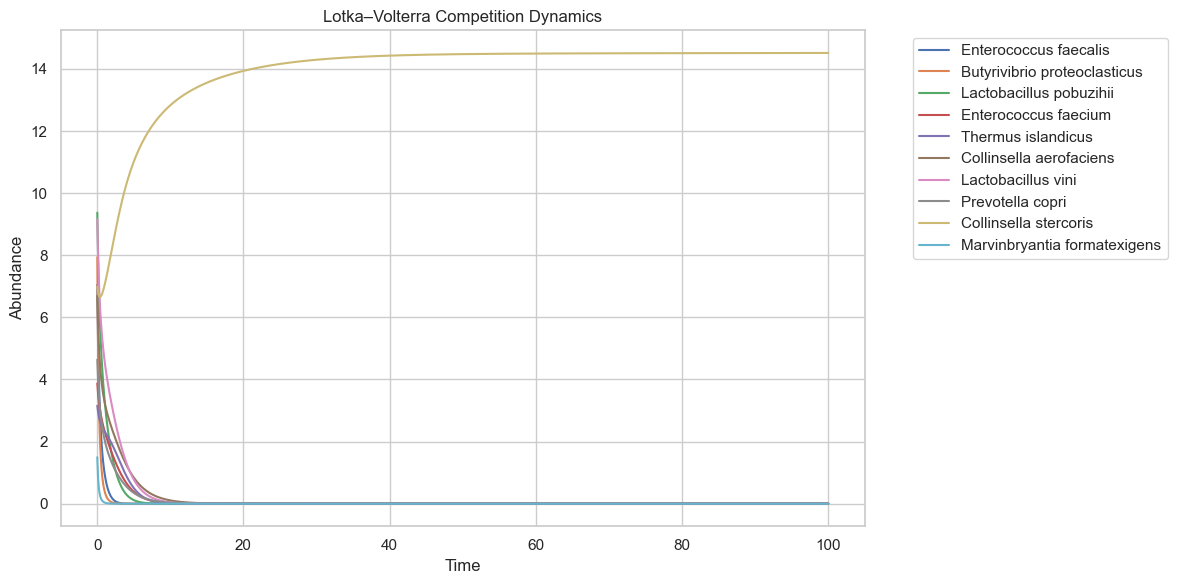

In [74]:
plt.figure(figsize=(12,6))

for i in range(min(10, n)):

    plt.plot(
        t,
        solution[:, i],
        label=species[i]
    )

plt.xlabel("Time")
plt.ylabel("Abundance")

plt.title(
    "Lotka–Volterra Competition Dynamics"
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

In [76]:
max_weight = max(
    d["weight"]
    for _, _, d in competition_graph.edges(data=True)
)

A = np.zeros((n, n))

for u, v, d in competition_graph.edges(data=True):

    i = species_index[u]
    j = species_index[v]

    value = d["weight"] / max_weight

    A[i, j] = value
    A[j, i] = value

A = -A

np.fill_diagonal(A, -1.0)

def glv(N, t, r, A):

    return N * (
        r + A @ N
    )

N0 = np.random.uniform(
    0.1,
    1.0,
    n
)

r = np.random.uniform(
    0.5,
    1.5,
    n
)

In [78]:
from scipy.integrate import odeint

t = np.linspace(0, 200, 2000)

solution = odeint(
    glv,
    N0,
    t,
    args=(r, A)
)

final_abundances = solution[-1]

survivors = np.sum(
    final_abundances > 1e-3
)

print(survivors)

398


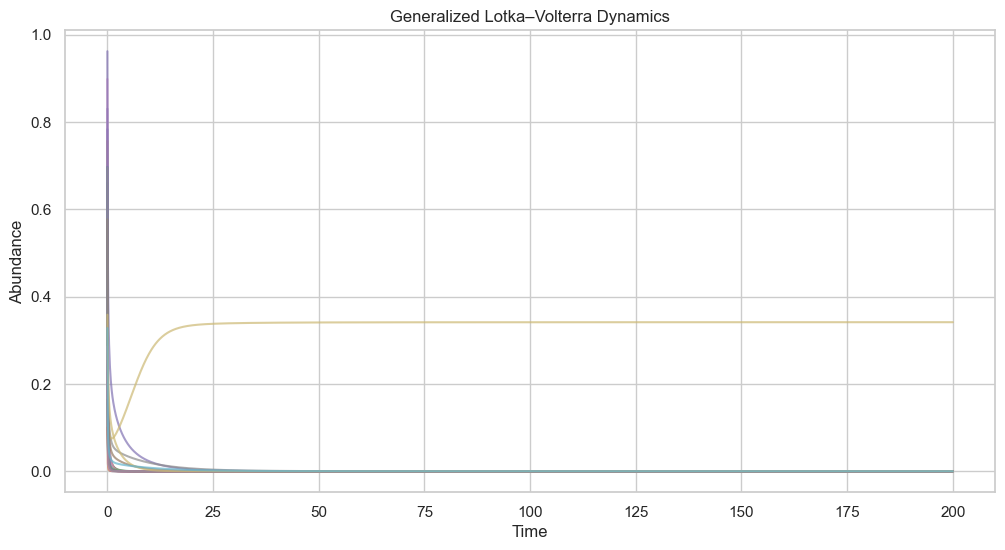

In [79]:
plt.figure(figsize=(12,6))

for i in range(min(20, n)):

    plt.plot(
        t,
        solution[:, i],
        alpha=0.7
    )

plt.xlabel("Time")
plt.ylabel("Abundance")

plt.title(
    "Generalized Lotka–Volterra Dynamics"
)

plt.show()

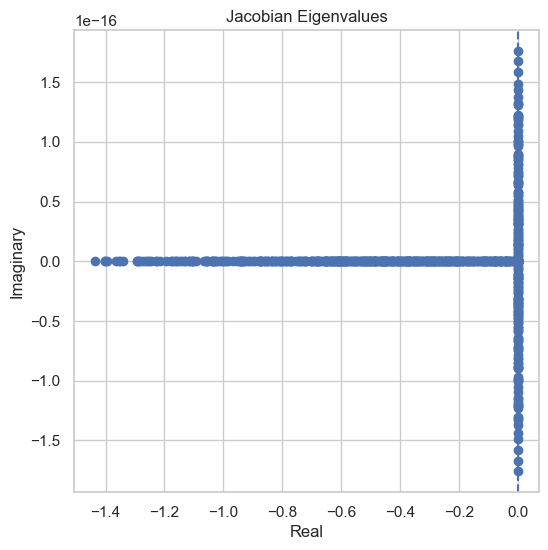

In [80]:
equilibrium = solution[-1]
J = np.diag(equilibrium) @ A
eigenvalues = np.linalg.eigvals(J)

plt.figure(figsize=(6,6))

plt.scatter(
    eigenvalues.real,
    eigenvalues.imag
)

plt.axvline(0, linestyle="--")

plt.xlabel("Real")
plt.ylabel("Imaginary")

plt.title("Jacobian Eigenvalues")

plt.show()